In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  LabelEncoder, StandardScaler
from pathlib import Path

path = "../df_encoded.csv"
df_encoded = pd.read_csv(path) #df = nome standardizzato per DataFrame

df_encoded.shape, df_encoded.head(), df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    int64  
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    int64  
 5   productivity_rating              500 non-null    int64  
 6   mood_rating                      500 non-null    int64  
 7   side_effects                     500 non-null    int64  
 8   alertness_delta                  500 non-null    int64  
 9   occupation_Freelancer            500 non-null    bool   
 10  occupation_Student               500 non-null    bool   
 11  occupation_Working Professional  500 non-null    bool   
dtypes: bool(3), float64(1), int64(8)


((500, 12),
    participant_id  age  sleep_hours_previous_night  intervention_type  \
 0               1   24                         5.4                  1   
 1               2   37                         5.6                  1   
 2               3   32                         4.4                  0   
 3               4   28                         6.9                  0   
 4               5   25                         4.7                  1   
 
    intervention_duration_minutes  productivity_rating  mood_rating  \
 0                             15                    5           10   
 1                             30                    6            5   
 2                             30                    2            5   
 3                             30                    4            6   
 4                             30                    3            6   
 
    side_effects  alertness_delta  occupation_Freelancer  occupation_Student  \
 0             2               15 

Ripetiamo le analisi del file "PCA_and_Clustering" escludendo le entry contenenti NaN nel campo "side_effects" del record originale, per avere eventuali indizzi sul fatto se questi indicassero "No side effects" od effettivamente un NaN.

In questo notebook facciamo alcune analisi con metodi unsupervised; prima facciamo una analisi basata su PCA, poi proveremo tecniche di clustering (k-means). In questo modo cerchiamo di avere un'idea più precisa della forma dei nostri dati.

In [13]:
X = df_encoded.drop(df_encoded[df_encoded["side_effects"]==3].index,axis=0) # Rimuovo i soggetti per cui nel record originale i side effect erano segnati come NaN

In [14]:
df_y = X["side_effects"]                             # Target variable

In [15]:
X = X.drop(["participant_id","side_effects"],axis=1) # Features matrix

In [16]:
side_effects_dict = {3:'No side effects', 2:'Grogginess', 1:'Crash', 0:'Anxiety'}

In [17]:
df_y = df_y.replace(side_effects_dict) # Riassegno le etichette ai rispettivi valori numerici dei side effects per maggiore interpretabilità nei grafici

In [18]:
X["alertness_delta"].unique()

array([15,  8, 11, 18, 20, 12,  9, 16, 21, 13, 19,  7, 17,  5, 10, 14, 23,
       24,  6, 22])

In [19]:
df_y.head()

0    Grogginess
2       Anxiety
3         Crash
4    Grogginess
7    Grogginess
Name: side_effects, dtype: object

In [20]:
X[["occupation_Freelancer","occupation_Student","occupation_Working Professional"]] = X[["occupation_Freelancer","occupation_Student","occupation_Working Professional"]].astype(int)

In [21]:
X.head()

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
0,24,5.4,1,15,5,10,15,0,0,1
2,32,4.4,0,30,2,5,8,0,0,1
3,28,6.9,0,30,4,6,11,0,1,0
4,25,4.7,1,30,3,6,18,0,0,1
7,43,4.4,1,25,5,10,20,0,1,0


In [22]:
scaler = StandardScaler()

In [23]:
X_scaled = scaler.fit_transform(X) # Normalize features

In [24]:
z = X["alertness_delta"].unique()
z.sort()
print(z)

[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


In [25]:
X_scaled = pd.DataFrame(data = X_scaled, columns = X.columns)
X_scaled.head()

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
0,-0.853207,-0.577410,1.200694,-1.331061,-0.125580,1.593649,0.354708,-0.644561,-0.815336,1.501851
1,0.150264,-1.468774,-0.832851,1.334093,-1.166949,-0.089621,-1.094509,-0.644561,-0.815336,1.501851
2,-0.351472,0.759637,-0.832851,1.334093,-0.472703,0.247033,-0.473416,-0.644561,1.226488,-0.665845
3,-0.727773,-1.201365,1.200694,1.334093,-0.819826,0.247033,0.975801,-0.644561,-0.815336,1.501851
4,1.530036,-1.468774,1.200694,0.445708,-0.125580,1.593649,1.389863,-0.644561,1.226488,-0.665845


In [26]:
z = X_scaled["alertness_delta"].unique()
z.sort()
print(z)

[-1.71560162 -1.50857062 -1.30153961 -1.09450861 -0.88747761 -0.68044661
 -0.4734156  -0.2663846  -0.0593536   0.1476774   0.35470841  0.56173941
  0.76877041  0.97580141  1.18283242  1.38986342  1.59689442  1.80392542
  2.01095643  2.21798743]


# Analisi PCA

Proviamo a controllare quante componenti principali sono necessarie per descrivere le features.

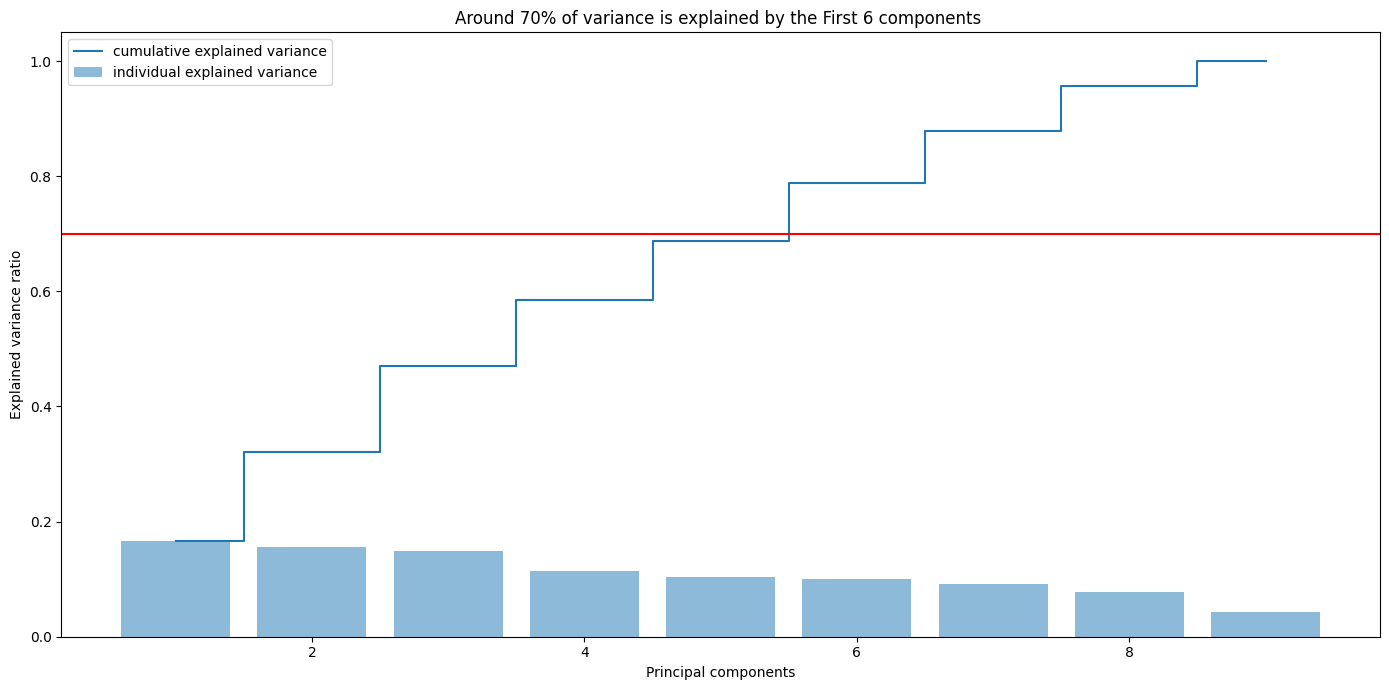

In [27]:
from sklearn.decomposition import PCA
ncomp = 9
pcan = PCA(n_components=ncomp)
pcan.fit(X_scaled.values)

plt.figure(1, figsize=(14, 7))
plt.bar(range(1,ncomp+1,1), pcan.explained_variance_ratio_, alpha=0.5, align='center',
        label='individual explained variance')
plt.step(range(1,ncomp+1,1),pcan.explained_variance_ratio_.cumsum(), where='mid',
         label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title(f"Around 70% of variance is explained by the First {6} components ");
plt.legend(loc='best')
plt.axhline(y=0.7, color='r', linestyle='-') # 70% of  explained variance
plt.tight_layout()

Vediamo dunque che le nostre feature hanno bisogno di 5-6 componenti principali perché almeno il 70 % della loro varianza sia spiegata. Proviamo comunque a visualizzare i dati con una proiezione 2D.

In [28]:
ncomp = 2
pcan = PCA(n_components=ncomp) 
# per evitare confusione, definiamo due oggetti distinti, pc_np e pc_df
pc_np = pcan.fit_transform(X_scaled.values) 
# pc_np sarà sempre un array numpy e conterrà le componenti principali di volta in volta considerate
pc_df = pd.DataFrame(data = pc_np, columns = ["PC1","PC2"])
# pc_df sarà sempre un oggetto DataFrame conterrà le componenti principali di volta in volta considerate e, eventualmente, una ulteriore colonna considerata come colonna di label/target


In [29]:
pc_df["target"] = df_y # Qui la colonna target contiene il vero target, cioè i side effects
pc_df["target"].head()

0    Grogginess
1           NaN
2       Anxiety
3         Crash
4    Grogginess
Name: target, dtype: object

In [30]:
pc_df.head()

,PC1,PC2,target
0,-1.470532,1.089712,Grogginess
1,0.519448,2.154925,NaN
2,1.620212,-0.750214,Anxiety
3,-1.357060,0.515917,Crash
4,-0.193684,-1.575224,Grogginess


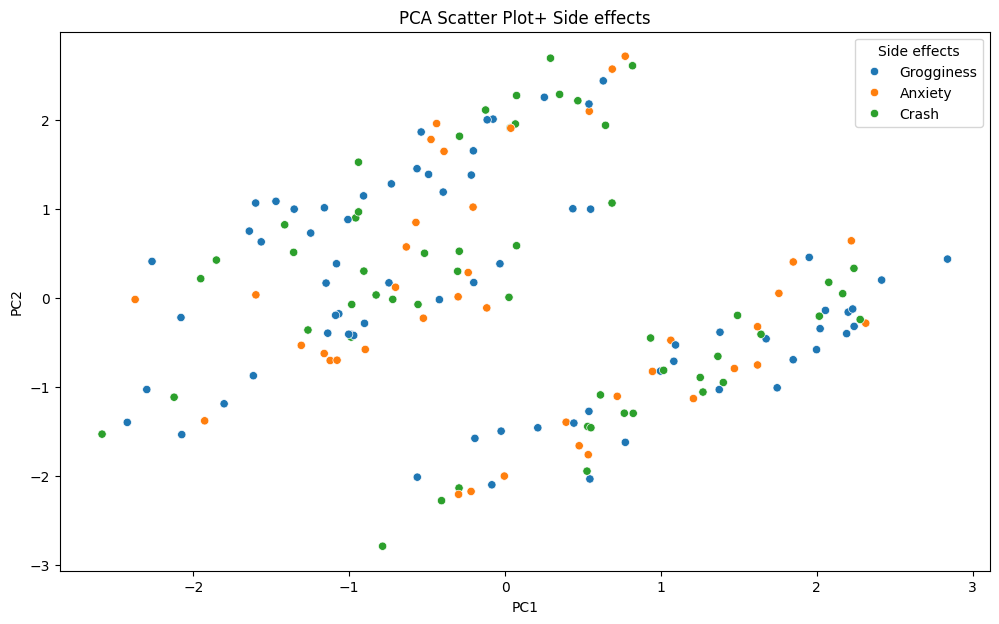

In [31]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="target")  # Grouping data points with different colors
plt.legend(title = 'Side effects')
plt.title('PCA Scatter Plot+ Side effects')
plt.show()

Vediamo che sembrano comparire due-tre fasce di dati. 

In [32]:
pc_df.drop("target", axis=1, inplace=True)
pc_df["target"] = ((X_scaled["alertness_delta"]>0).astype(int)).map({0:'Alertness delta<0',1:'Alertness delta>0'}) 
# Inseriamo come target una variabile che vale 1 se Alertness delta>0 e vale 0 se Alertness delta<0

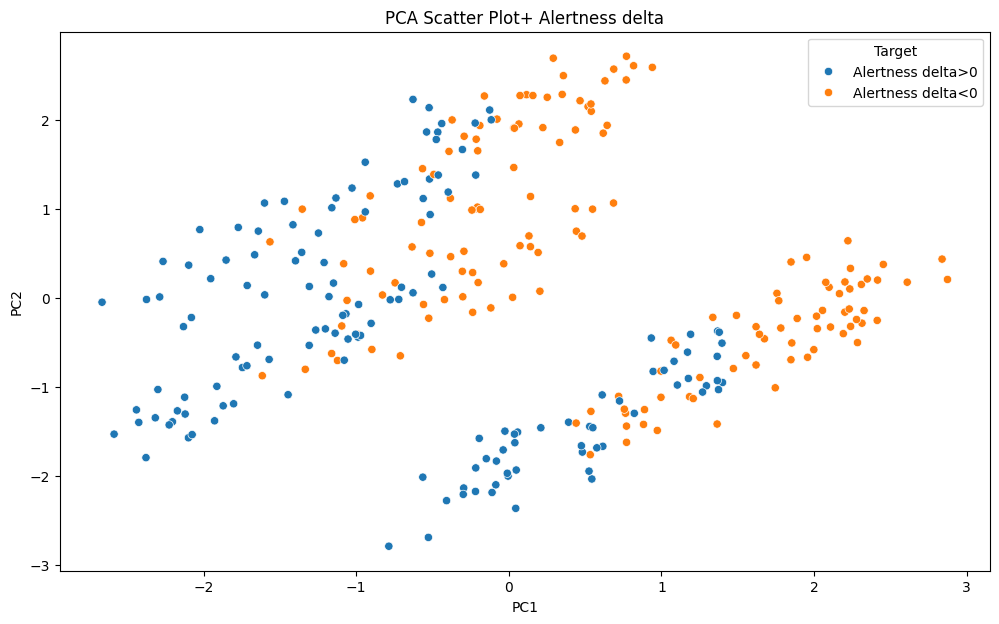

In [33]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Alertness delta')
plt.legend(title='Target')
plt.show()

Dunque, i due cluster non sono semplicemente dovuti a se l'alertness delta è >0 o no.

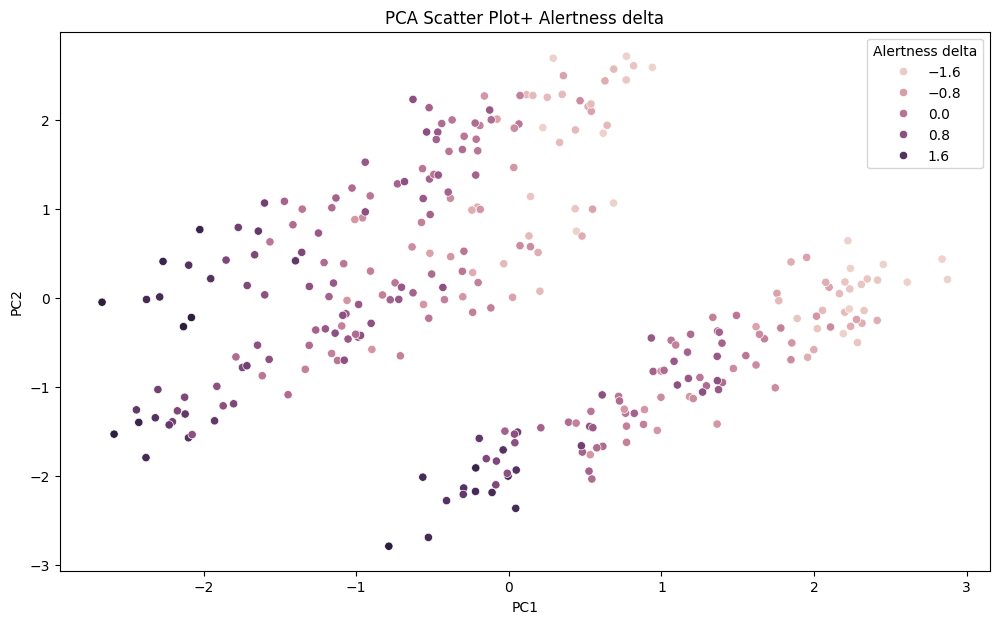

In [34]:
pc_df.drop("target", axis=1, inplace=True)
pc_df["target"] = X_scaled["alertness_delta"]
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target", legend= "auto" # Grouping data points with different colors
)
plt.legend(title='Alertness delta')
plt.title('PCA Scatter Plot+ Alertness delta')
plt.show()

N.B.: l'opzione legend="auto" visualizza solo 5 valori per l'alertness delta, e in effetti plottare tutti i valori con l'opzione legend="full" non dà più informazioni visive utili.

Da questo plot, sembra che la direzione ascendente dei due cluster sia associata al delta alertness. 
Dal confronto col primo grafico, "Crash" e "Anxiety" sembrano associate ad un delta alertness<0 e "Grogginess" ad un delta alertness>0, mentre "No side effects" non sembra essere influenzata dal valore della delta alertness.

Proviamo adesso a tracciare effettivamente le proiezioni delle direzioni associate alle features.

In [35]:
feature_names = X_scaled.columns
feature_names

Index(['age', 'sleep_hours_previous_night', 'intervention_type',
       'intervention_duration_minutes', 'productivity_rating', 'mood_rating',
       'alertness_delta', 'occupation_Freelancer', 'occupation_Student',
       'occupation_Working Professional'],
      dtype='str')

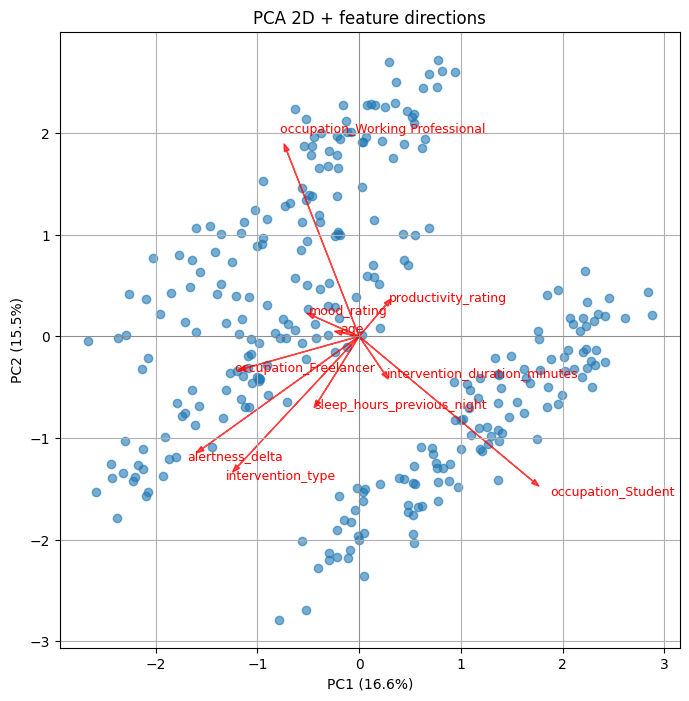

In [36]:
pcan = PCA(n_components=2)
pc_np = pcan.fit_transform(X_scaled.values)

plt.figure(figsize=(8,8))
plt.scatter(pc_np[:,0], pc_np[:,1], alpha=0.6)

arrow_scale = 3  # tune
for i, feat in enumerate(feature_names):
    x, y = pcan.components_[0, i], pcan.components_[1, i]
    plt.arrow(0, 0, x*arrow_scale, y*arrow_scale,
              color='red', alpha=0.7, width=0.002, head_width=0.05)
    plt.text(x*arrow_scale*1.1, y*arrow_scale*1.1, feat,
             color='red', fontsize=9)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC1 (%.1f%%)' % (pcan.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pcan.explained_variance_ratio_[1]*100))
plt.title('PCA 2D + feature directions')
plt.grid(True)
plt.show()

Quindi, sembra che i due cluster siano in grande parte determinati dall'essere uno studente o un freelancer.

Proviamo anche a visualizzare il plot delle prime 3 componenti principali e delle componenti principali dalla quarta alla sesta

C:\Users\Paolo\AppData\Local\Temp\ipykernel_27040\87177861.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Side effects')


<Figure size 2000x1500 with 0 Axes>

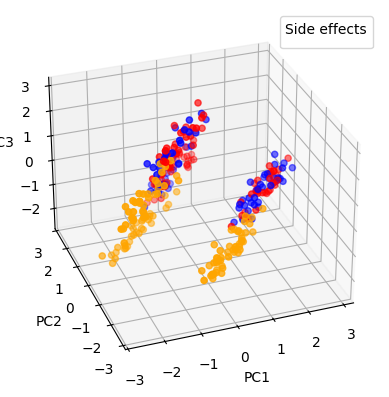

In [ ]:
#3D scatter plot
pcan = PCA(n_components=3)
pc_np = pcan.fit_transform(X_scaled.values)


fig = plt.figure(figsize=(20,15))
ax = plt.figure().add_subplot(projection='3d') # creates a 3D axis 

cmap = {'No side effects':'green','Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

ax.scatter(pc_np[:,0], pc_np[:,1], pc_np[:,2], c=[cmap[c] for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(30,-110)
plt.legend(title='Side effects')
plt.show()


C:\Users\Paolo\AppData\Local\Temp\ipykernel_27040\3812577393.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Side effects')


<Figure size 2000x1500 with 0 Axes>

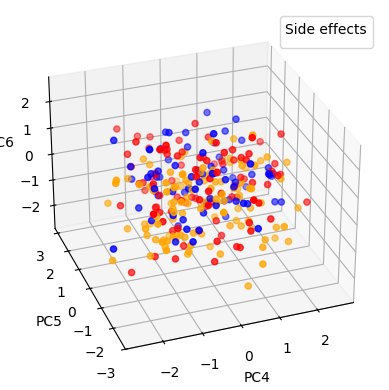

In [ ]:
#3D scatter plot
pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled.values)

fig = plt.figure(figsize=(20,15))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'No side effects':'green','Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}


# ax.scatter(pc3[:,0], pc3[:,1], pc3[:,2], c=[cmap[c] for c in  df_y], marker='o', s=20)
ax.scatter(pc_np[:,3], pc_np[:,4], pc_np[:,5], c=[cmap[c] for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC4')
ax.set_ylabel('PC5')
ax.set_zlabel('PC6')
ax.view_init(30,-110)
plt.legend(title='Side effects')
plt.show()


In definitiva, probabilmente questa analisi con PCA non ci dice molto, se non che i dati sono 5-6- dimensionali, e che le features più importanti per i primi due fattori sono l'alertness delta, il tipo di trattamento e le variabili relative all'occupazione.

Pertanto, almeno guardando solo le prime due componenti, potremmo preservare solo queste variabili senza perdere molte informazioni; questo però andrebbe verificato meglio, visto che le restanti variabili potrebbero essere importanti per i fattori 3-6.

# Clustering k-means

Proviamo ora a fare un clustering k-means.

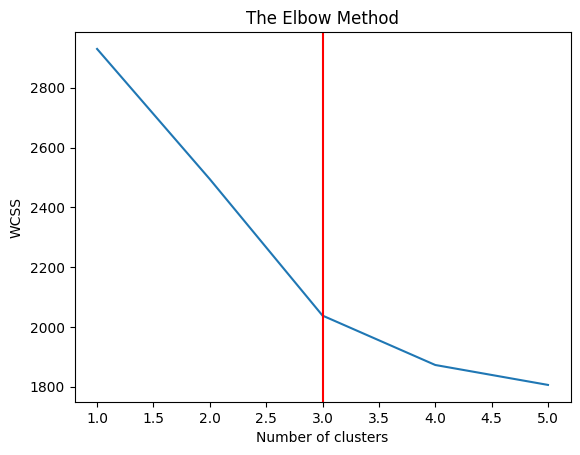

In [39]:
from sklearn.cluster import KMeans

wcss = [] # within cluster sum of squares
n_clusters = 5

for i in range(1, n_clusters+1):
    #Compute kmeans for different values of k. For instance, by varying k from 1 to 5 clusters
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) # k-means++ is an algorithm for choosing a good initial centroids. 
    # For each k, calculate the total within-cluster sum of square (wss)
    kmeans.fit(X_scaled.to_numpy())
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, n_clusters+1), wcss)#, xticks=range(6)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.axvline(x=3, color='r', linestyle='-')
plt.show()

Sembra che la varianza spiegata suggerisca 3 clusters, proprio come il numero di side effects considerati (Grogginess, Crash e Anxiety). Per completezza, proviamo a fare comunque il clustering sia con 3 che con 4 clusters.

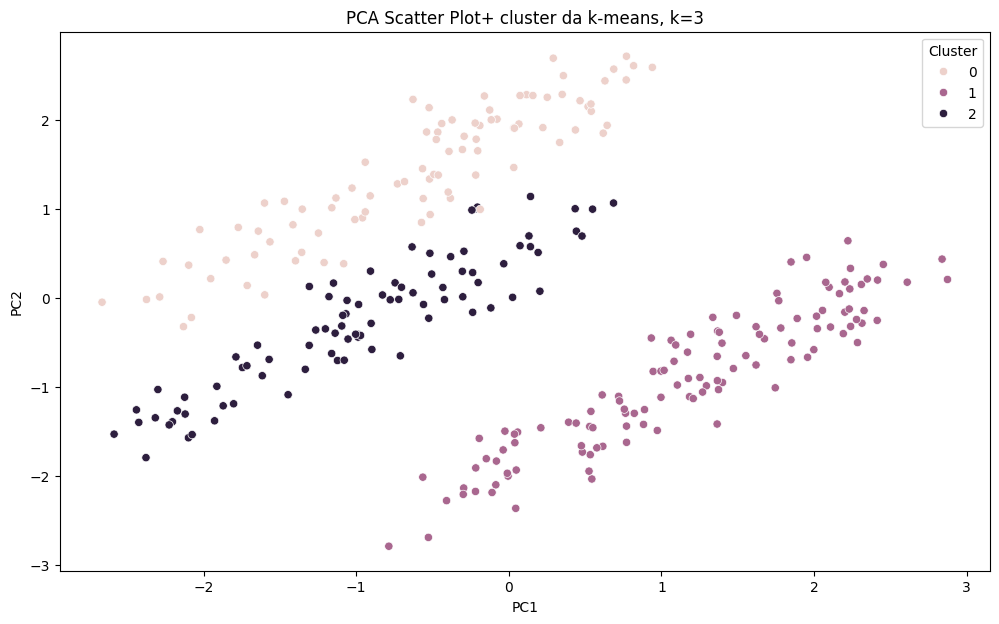

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
kmeans.fit(X_scaled)
pcan = PCA(n_components=2)
pc_np = pcan.fit_transform(X_scaled.values)
pc_df = pd.DataFrame(data=pc_np,columns=["PC1","PC2"])
pc_df['target'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ cluster da k-means, k=3')
plt.legend(title='Cluster')
plt.show()

Il k-means con 3 cluster sembra recuperare il cluster in alto e dividere il cluster in basso in una fascia superiore ed una inferiore. 

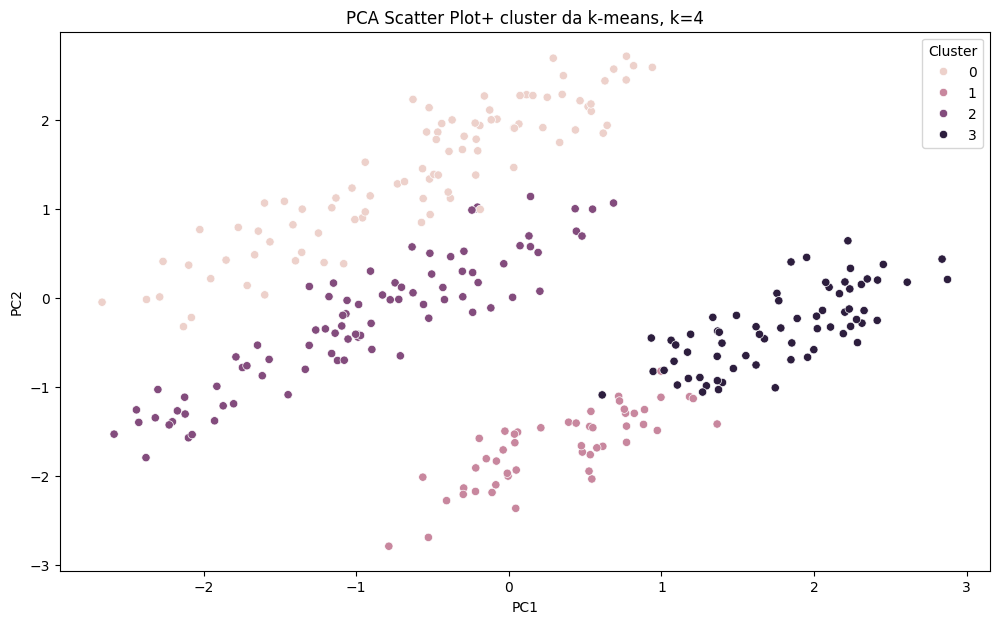

In [ ]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
kmeans.fit(X_scaled)
pcan = PCA(n_components=2)
# pc_np = pcan.fit_transform(X_scaled.values)
# pc_df = pd.DataFrame(data=pc_np,columns=["PC1","PC2"])
pc_df['target'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ cluster da k-means, k=4')
plt.legend(title='Cluster')
plt.show()

Il k-means con 4 cluster prende il gruppo in basso e lo divide in 2, secondo la direzione corrispondente all'alertness delta ed all'intervention type.

Proviamo adesso ad interpretare i cluster ottenuti con il metodo k-means con k=3 o 4. Proviamo quindi a confrontarli con le distribuzioni delle features.

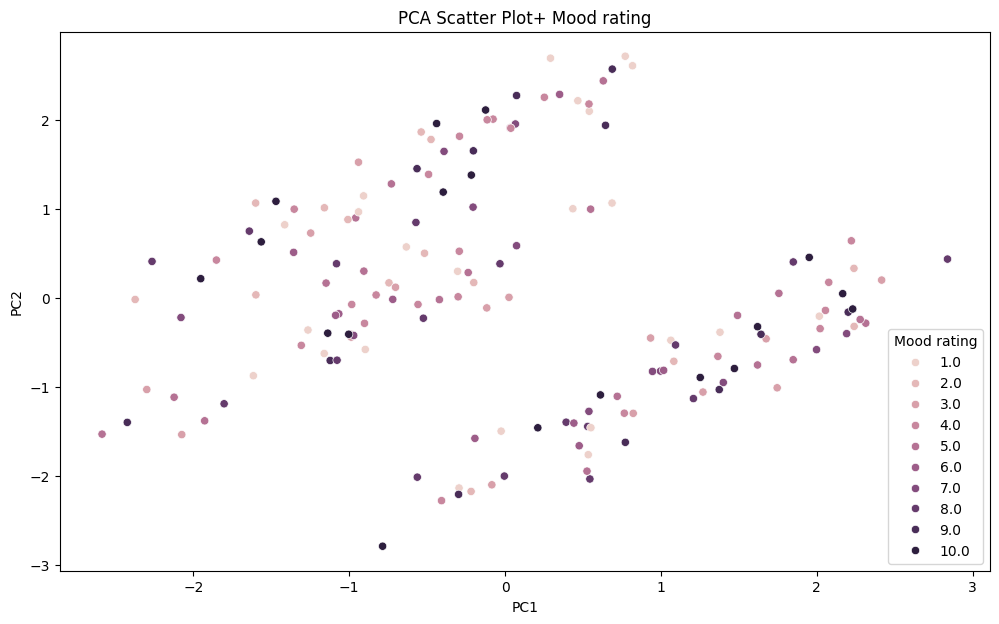

In [42]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X.mood_rating
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target",legend="full" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Mood rating')
plt.legend(title='Mood rating')
plt.show()

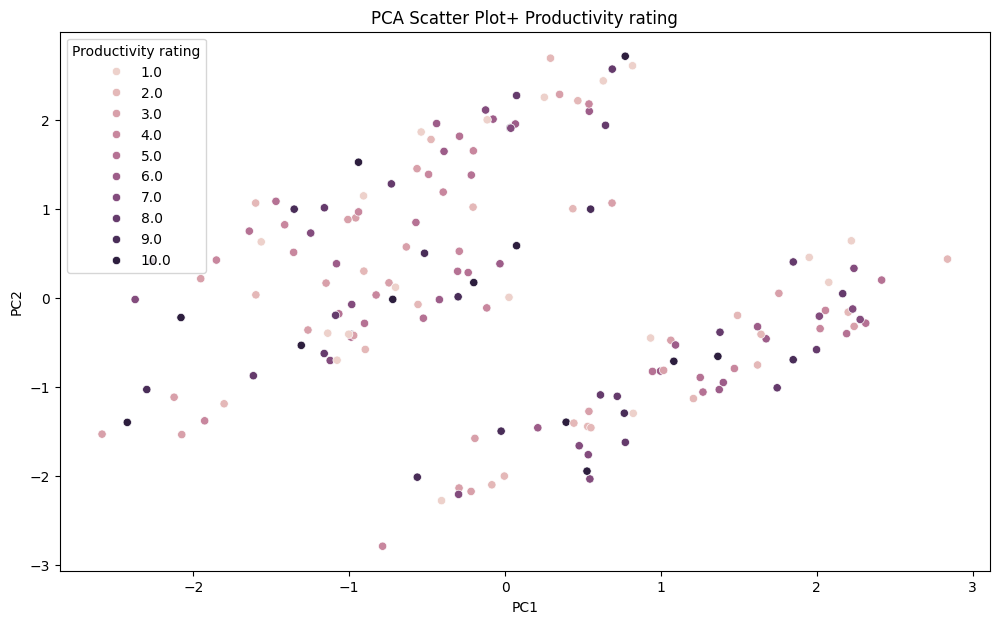

In [43]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X["productivity_rating"]
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target", legend='full' # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Productivity rating')
plt.legend(title='Productivity rating')
plt.show()

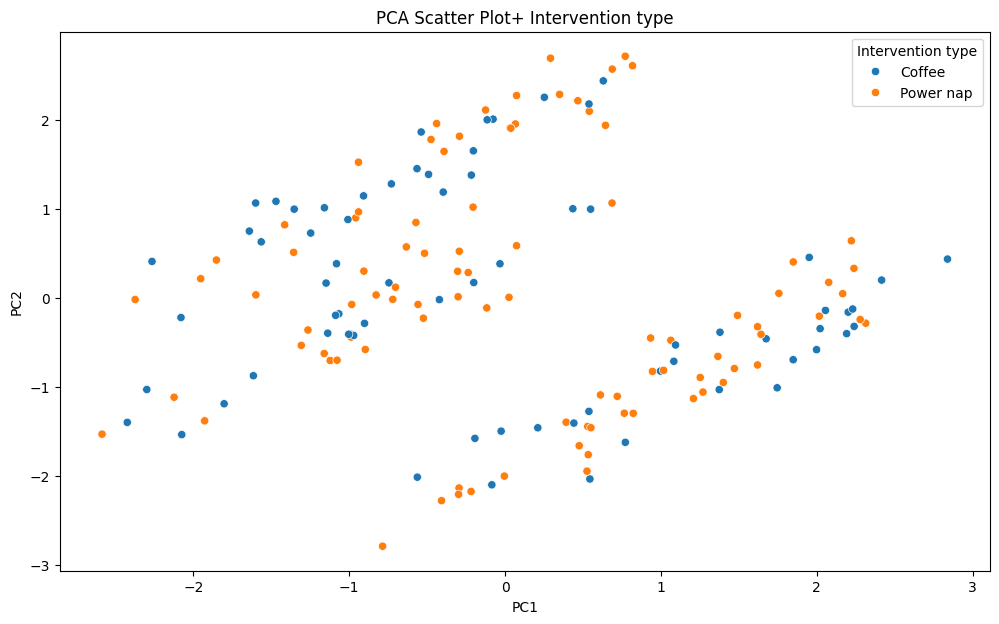

In [44]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X["intervention_type"].replace({0:'Power nap',1:'Coffee'})
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Intervention type')
plt.legend(title='Intervention type')
plt.show()

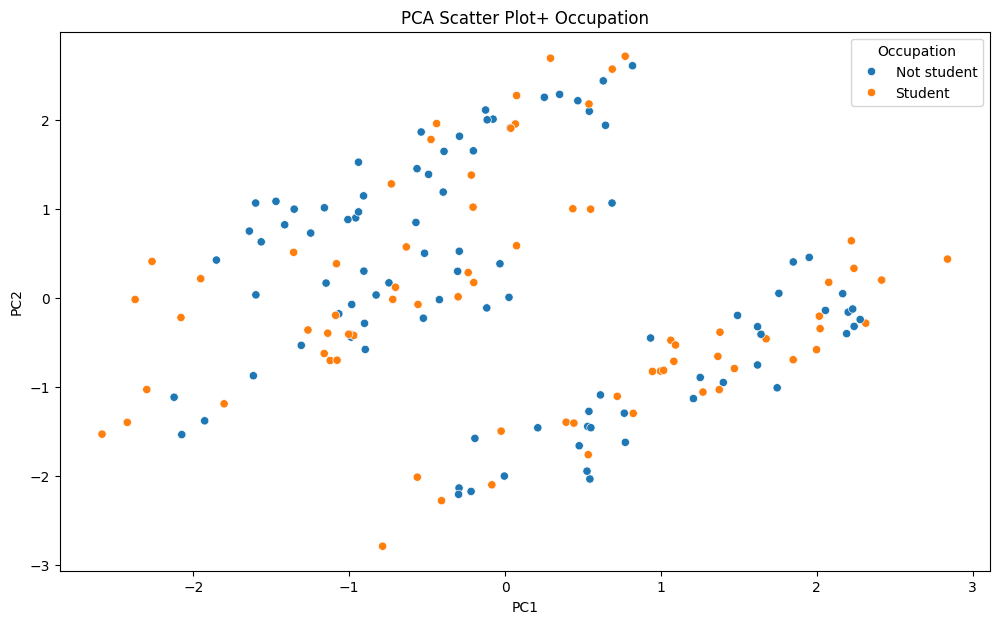

In [45]:
pc_df["target"] = X["occupation_Student"].map({0: 'Not student', 1: 'Student'})
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Occupation')
plt.legend(title='Occupation')
plt.show()

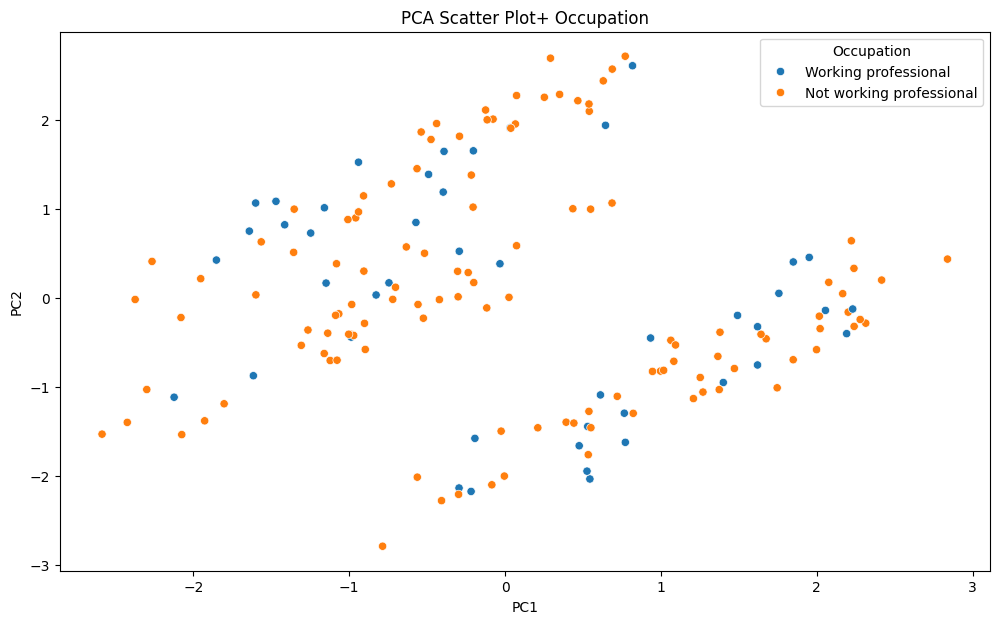

In [46]:
pc_df["target"] = X["occupation_Working Professional"].map({0: 'Not working professional', 1: 'Working professional'})
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Occupation')
plt.legend(title='Occupation')
plt.show()

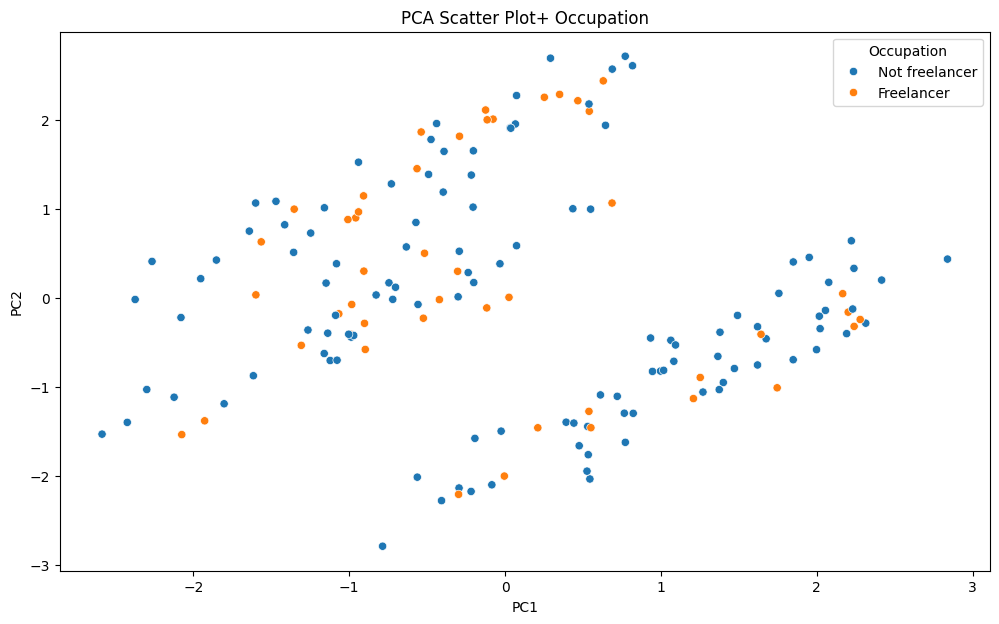

In [47]:
pc_df["target"] = X["occupation_Freelancer"].map({0: 'Not freelancer', 1: 'Freelancer'})
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Occupation')
plt.legend(title='Occupation')
plt.show()

Quindi, i tre cluster trovati con k-means con k=3 corrispondono ai cluster degli studenti, dei lavoratori e dei freelancer. 
Quelli con k=4 corrispondono più o meno agli stessi gruppi, dove però quello dei lavoratori viene diviso in base all'intervention type (power nap per la direzione verso l'alto e caffè per quella verso il basso).

In definitiva, anche l'analisi tramite k-means non è granché conclusiva, visto che non riesce a spiegare (o comunque a dare informazioni su) la variabile relativa ai side effects. Questo però non è strano, visto che stiamo usando metodi unsurpervised.

N.B.: Ho effettuato il clustering con i dati scalati, visto la disomogeneità fra le diverse features.

# Analisi a prescindere dall'occupazione

Sembra che i cluster individuati finora siano soprattutto associati alle 3 variabili relative all'occupazione, che erano state codificate tramite one-hot encoding da una singola variabile categorica con tre valori. Anche la (relativamente) alta dimensionalità dei dati potrebbe essere dovuta a queste variabili.

Proviamo dunque a ripetere le precedenti visualizzazioni escludendo dalle features le variabili relative all'occupazione.

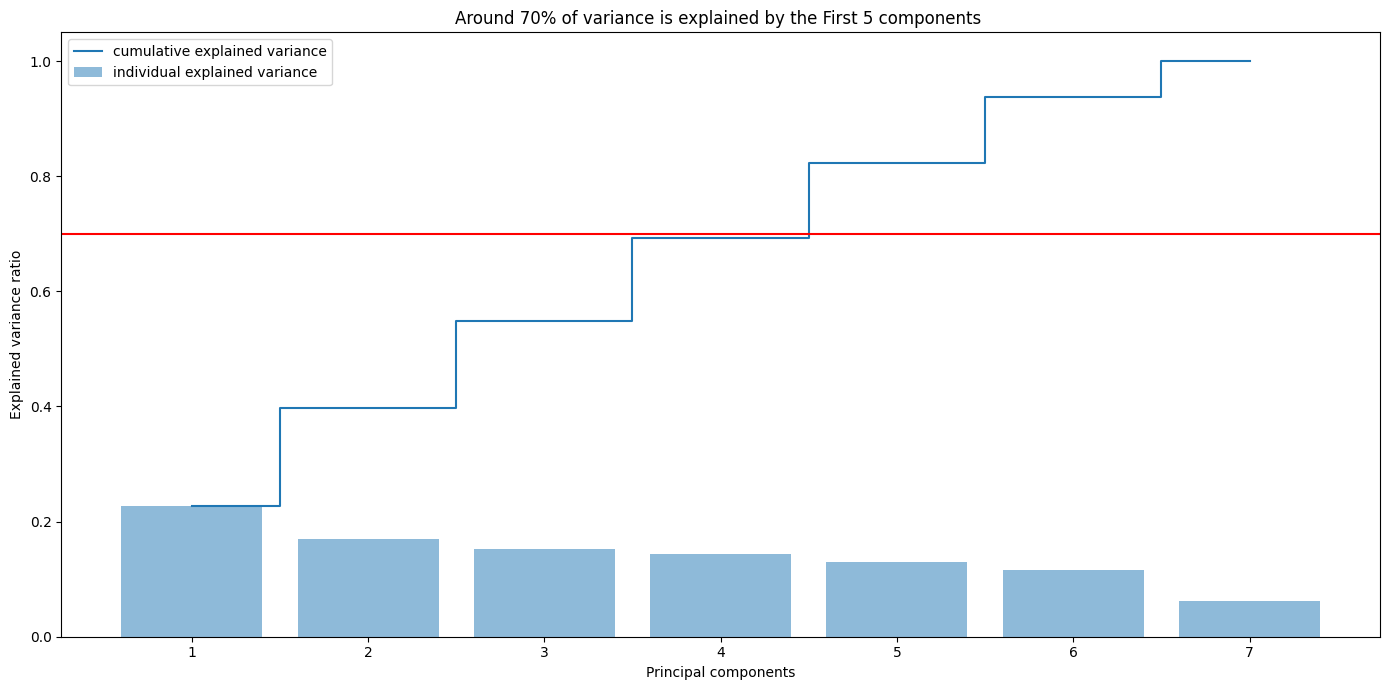

In [48]:
ncomp = 7
pcan = PCA(n_components=ncomp)

pcan.fit(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1).values)
plt.figure(1, figsize=(14, 7))
plt.bar(range(1,ncomp+1,1), pcan.explained_variance_ratio_, alpha=0.5, align='center',
        label='individual explained variance')
plt.step(range(1,ncomp+1,1),pcan.explained_variance_ratio_.cumsum(), where='mid',
         label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title(f"Around 70% of variance is explained by the First {5} components ");
plt.legend(loc='best')
plt.axhline(y=0.7, color='r', linestyle='-') # 70% of  explained variance
plt.tight_layout()

Dunque, anche escludendo le variabili relative all'occupazione, sono ancora necessarie 4-5 componenti principali per spiegare almeno il 70 % della varianza nei dati. 

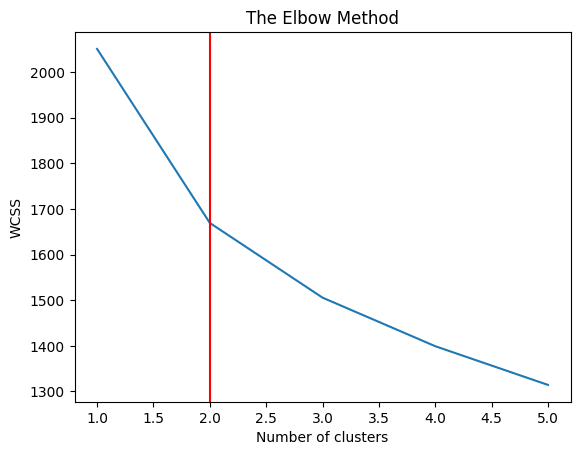

In [49]:
wcss = [] # within cluster sum of squares
n_clusters = 5

for i in range(1, n_clusters+1):
    #Compute kmeans for different values of k. For instance, by varying k from 1 to 5 clusters
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) # k-means++ is an algorithm for choosing a good initial centroids. 
    # For each k, calculate the total within-cluster sum of square (wss)
    kmeans.fit(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1).to_numpy())
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, n_clusters+1), wcss)#, xticks=range(6)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.axvline(x=2, color='r', linestyle='-')
plt.show()

L'Elbow Method sembra suggerire 2 o 3 cluster. Già con 2 cluster si otterrebbe una buona clusterizzazione.

Visualizziamo adesso con PCA i cluster ottenuti con k-means.

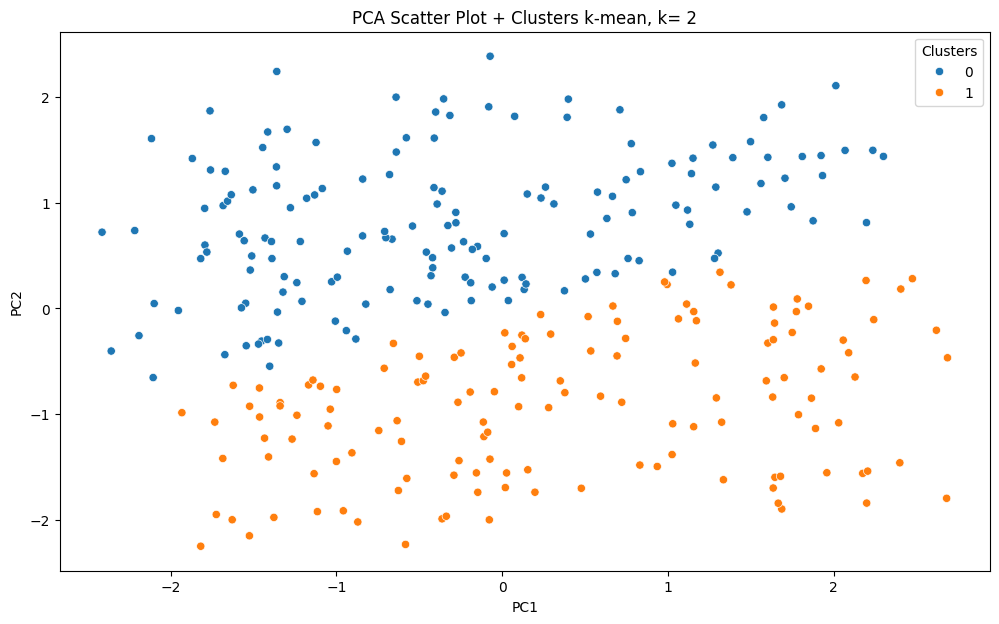

In [50]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)

pcan = PCA(n_components=2)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1).values)
pc_df = pd.DataFrame(data=pc_np,columns=["PC1","PC2"])
kmeans.fit(pc_np)
pc_df['target'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot + Clusters k-mean, k= 2')
plt.legend(title='Clusters')
plt.show()

In [60]:
pc_np.shape

(293, 6)

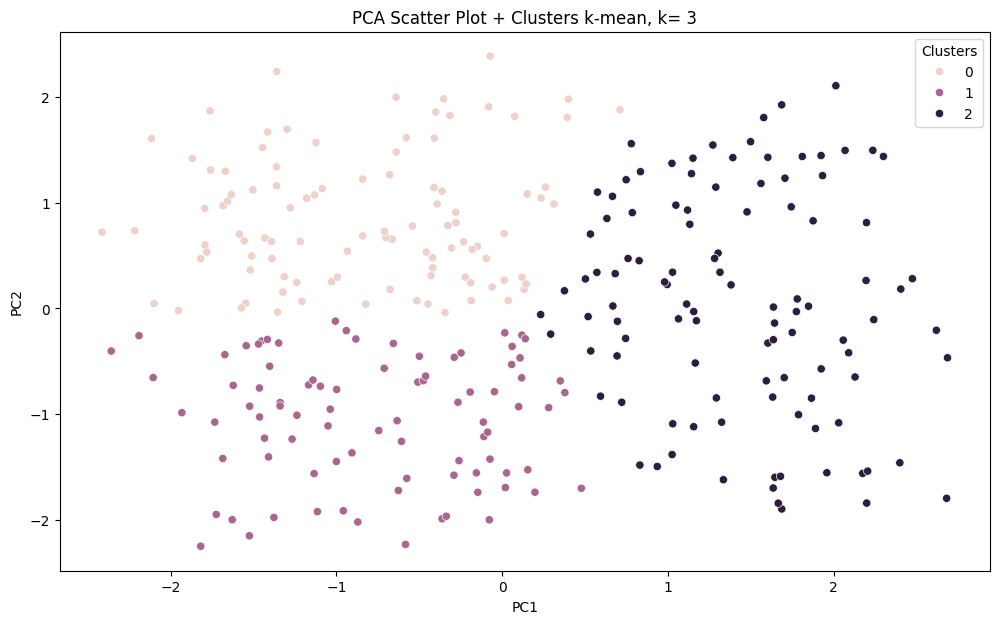

In [62]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)

pcan = PCA(n_components=2)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1).values)

kmeans.fit(pc_np)
pc_df = pd.DataFrame(data = pc_np, columns = ["PC1","PC2"])
pc_df['target'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot + Clusters k-mean, k= 3')
plt.legend(title='Clusters')
plt.show()

Dunque il clustering k-means non è molto efficace per la visualizzazione sulle prime 2 componenti principali, se si eliminano le variabili relative all'occupazione. 

Vediamo come si dispongono le proiezioni delle direzioni associate alle features sulle prime componenti principali.

In [52]:
feature_names = X.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1).columns

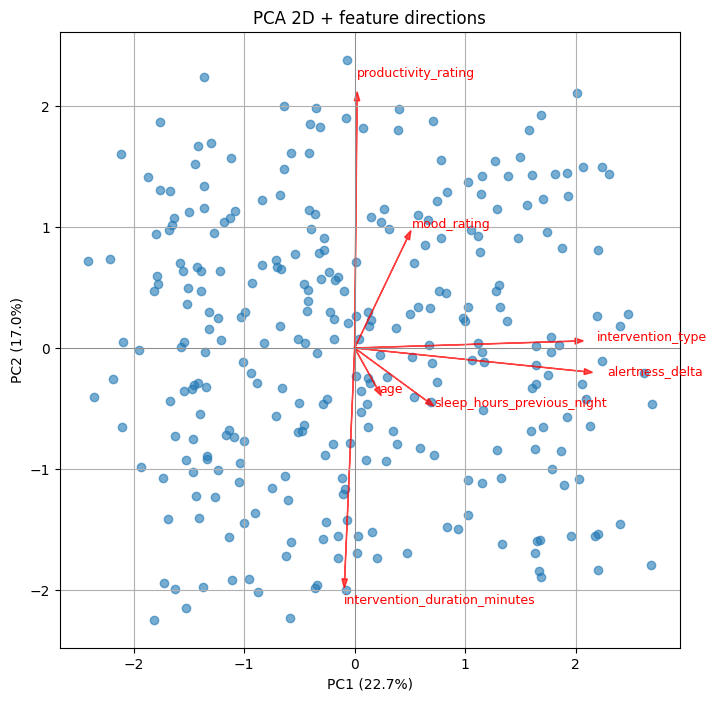

In [53]:
pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"],axis=1))

plt.figure(figsize=(8,8))
plt.scatter(pc_np[:,0], pc_np[:,1], alpha=0.6)

arrow_scale = 3  # tune
for i, feat in enumerate(feature_names):
    x, y = pcan.components_[0, i], pcan.components_[1, i]
    plt.arrow(0, 0, x*arrow_scale, y*arrow_scale,
              color='red', alpha=0.7, width=0.002, head_width=0.05)
    plt.text(x*arrow_scale*1.1, y*arrow_scale*1.1, feat,
             color='red', fontsize=9)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC1 (%.1f%%)' % (pcan.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pcan.explained_variance_ratio_[1]*100))
plt.title('PCA 2D + feature directions')
plt.grid(True)
plt.show()

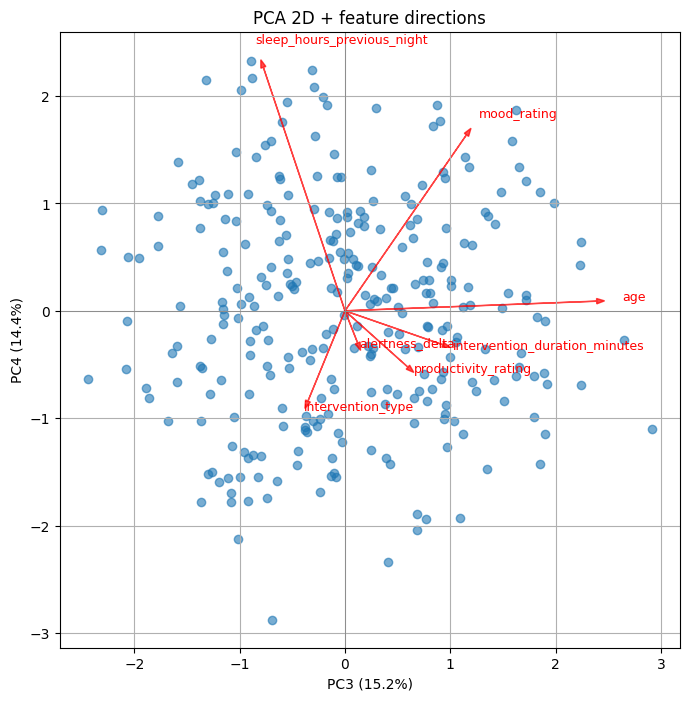

In [54]:
pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student","occupation_Working Professional","occupation_Freelancer"], axis=1))

plt.figure(figsize=(8,8))
plt.scatter(pc_np[:,2], pc_np[:,3], alpha=0.6)

arrow_scale = 3  # tune
for i, feat in enumerate(feature_names):
    x, y = pcan.components_[2, i], pcan.components_[3, i]
    plt.arrow(0, 0, x*arrow_scale, y*arrow_scale,
              color='red', alpha=0.7, width=0.002, head_width=0.05)
    plt.text(x*arrow_scale*1.1, y*arrow_scale*1.1, feat,
             color='red', fontsize=9)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC3 (%.1f%%)' % (pcan.explained_variance_ratio_[2]*100))
plt.ylabel('PC4 (%.1f%%)' % (pcan.explained_variance_ratio_[3]*100))
plt.title('PCA 2D + feature directions')
plt.grid(True)
plt.show()

<Figure size 1200x700 with 0 Axes>

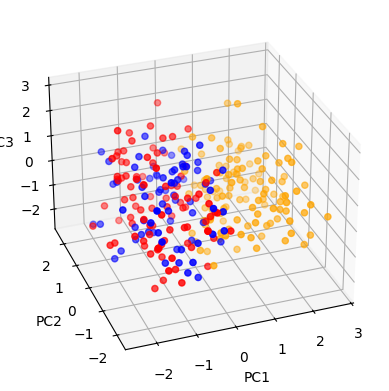

In [ ]:
#3D scatter plot
pcan = PCA(n_components=3)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student", "occupation_Working Professional", "occupation_Freelancer"], axis=1))

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'No side effects':'green','Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

# ax.scatter(pc3[:,0], pc3[:,1], pc3[:,2], c=[cmap[c] for c in  df_y], marker='o', s=20)
ax.scatter(pc_np[:,0], pc_np[:,1], pc_np[:,2], c=[cmap[c] for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(30,-110)
plt.show()

Da questo plot i valori Grogginess sono divisi da quelli Crash e Anxiety, che invece sono mescolati.

<Figure size 1200x700 with 0 Axes>

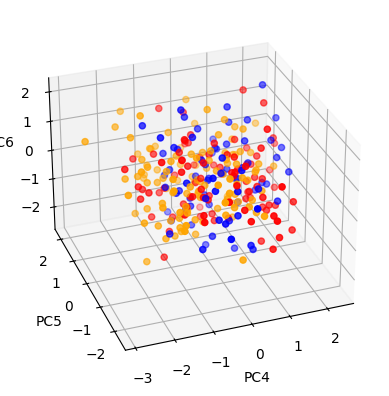

In [ ]:
#3D scatter plot
pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled.drop(["occupation_Student", "occupation_Working Professional", "occupation_Freelancer"], axis=1))

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'No side effects':'green','Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

# ax.scatter(pc3[:,0], pc3[:,1], pc3[:,2], c=[cmap[c] for c in  df_y], marker='o', s=20)
ax.scatter(pc_np[:,3], pc_np[:,4], pc_np[:,5], c=[cmap[c] for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC4')
ax.set_ylabel('PC5')
ax.set_zlabel('PC6')
ax.view_init(30,-110)
plt.show()

Nello spazio PC4-PC5-PC6 non sembra che ci siano dei cluster ben divisi.